# Grain-128 Cipher

## Overview
- **Cipher**: Grain-128 (stream cipher with 128-bit key and 96-bit IV)
- **Models used**: Logistic Regression, MLP, CNN
- **Analysis done through**: Bitwise accuracy, Hamming distance, Generalization


## 1. Setup and Imports

In [1]:
from __future__ import annotations

import os
import pickle
import hashlib
import time
import warnings
import torch
import sklearn

warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.cuda.amp as amp
import matplotlib
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler

# Directories
os.makedirs("data/cache_grain",     exist_ok=True)
os.makedirs("data/cache_grain_gen", exist_ok=True)
os.makedirs("results_grain/models", exist_ok=True)

# Device setup
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = (DEVICE.type == "cuda")
print(f"Device  : {DEVICE}")

Device  : cuda


## 2. Grain-128 Cipher Implementation

Grain-128 is a hardware-oriented stream cipher. Key components:
- **LFSR** (Linear Feedback Shift Register) — 128 bits
- **NFSR** (Nonlinear Feedback Shift Register) — 128 bits  
- **h function** — non-linear output filter
- **Keystream** — XOR of h-function output and NFSR bit

In [2]:

def _bit(reg: list, i: int) -> int:
    return reg[i] & 1

def _int_to_bits_lsb(value: int, n: int) -> list:
   
    return [(value >> i) & 1 for i in range(n)]

def _bits_lsb_to_int(bits: list) -> int:
   
    result = 0
    for i, b in enumerate(bits):
        result |= (b & 1) << i
    return result

def _lfsr_feedback(s: list) -> int:

    return (s[0] ^ s[7] ^ s[38] ^ s[70] ^ s[81] ^ s[96]) & 1


def _nfsr_feedback(b: list, s: list) -> int:

    return (
        s[0] ^ b[0] ^ b[26] ^ b[56] ^ b[91] ^ b[96]
        ^ (b[3]  & b[67])
        ^ (b[11] & b[13])
        ^ (b[17] & b[18])
        ^ (b[27] & b[59])
        ^ (b[40] & b[48])
        ^ (b[61] & b[65])
        ^ (b[68] & b[84])
        ^ (b[88] & b[92] & b[93] & b[95])
        ^ (b[22] & b[24] & b[25])
        ^ (b[70] & b[78] & b[82])
    ) & 1


def _h_function(b: list, s: list) -> int:

    h = (
        (b[2]  & s[27])
        ^ (s[3]  & s[67])
        ^ (b[91] & s[76])
        ^ (s[93] & b[40])
        ^ (b[95] & b[22] & s[93])
    ) & 1
    linear = (b[12] ^ s[8] ^ b[95] ^ s[42] ^ s[60] ^ s[79] ^ s[94]) & 1
    return h ^ linear

In [3]:
class Grain128:

    LFSR_SIZE = 128
    NFSR_SIZE = 128
    KEY_BITS  = 128
    IV_BITS   = 96

    def __init__(self, key: int, iv: int, init_rounds: int = 256):
        assert 0 <= key < (1 << self.KEY_BITS)
        assert 0 <= iv  < (1 << self.IV_BITS)
        assert 1 <= init_rounds <= 256

        self.key         = key
        self.iv          = iv
        self.init_rounds = init_rounds
        self._lfsr, self._nfsr = self._load_and_init()

    def _load_and_init(self):
        key_bits = _int_to_bits_lsb(self.key, self.KEY_BITS)
        iv_bits  = _int_to_bits_lsb(self.iv,  self.IV_BITS)

        s = iv_bits[:] + [0] * 31 + [1]   # LFSR: IV ‖ 0…0 ‖ 1
        b = key_bits[:]                    # NFSR: key

        for _ in range(self.init_rounds):
            z  = _h_function(b, s) ^ b[0]
            nf = _nfsr_feedback(b, s)
            lf = _lfsr_feedback(s)
            b  = b[1:] + [(nf ^ z) & 1]
            s  = s[1:] + [(lf ^ z) & 1]

        return s, b

    def _clock(self) -> int:
        z  = _h_function(self._nfsr, self._lfsr) ^ self._nfsr[0]
        nf = _nfsr_feedback(self._nfsr, self._lfsr)
        lf = _lfsr_feedback(self._lfsr)
        self._nfsr = self._nfsr[1:] + [nf & 1]
        self._lfsr = self._lfsr[1:] + [lf & 1]
        return z & 1

    def keystream_bits(self, n: int) -> list:
        return [self._clock() for _ in range(n)]

    def keystream_int(self, n: int) -> int:
        return _bits_lsb_to_int(self.keystream_bits(n))


class Grain128Cipher:

    BLOCK_BITS = 128
    IV_BITS    = 96

    def __init__(self, key: int, init_rounds: int):
        assert 0 <= key < (1 << 128)
        assert 1 <= init_rounds <= 256
        self.key         = key
        self.init_rounds = init_rounds

    def encrypt(self, plaintext: int) -> int:
        iv = plaintext & ((1 << self.IV_BITS) - 1)
        return Grain128(self.key, iv, self.init_rounds).keystream_int(self.BLOCK_BITS)

## 3. Dataset Generation

For each `init_rounds` value, we generate `(IV_bits, keystream_bits)` pairs:
- **Input X**: 128-bit representation of the 96-bit IV (zero-padded)
- **Output y**: First 128 keystream bits

In [4]:
BLOCK_BITS = 128
IV_BITS    = 96
MAX_ROUNDS = 256
PATIENCE=6
LR=2e-3


def batch_int_to_bits_lsb(values: np.ndarray, num_bits: int) -> np.ndarray:

    shifts = np.arange(num_bits, dtype=np.int64)
    return ((values[:, None] >> shifts) & 1).astype(np.float32)


def bitwise_accuracy(y_true, y_pred):
    return float(np.mean((y_pred >= 0.5).astype(np.float32) == y_true))

def hamming_distance(y_true, y_pred):
    pred = (y_pred >= 0.5).astype(np.float32)
    return float(np.mean(np.sum(np.abs(pred - y_true), axis=1)))

def exact_match_accuracy(y_true, y_pred):
    pred = (y_pred >= 0.5).astype(np.float32)
    return float(np.mean(np.all(pred == y_true, axis=1)))

In [ ]:
def generate_dataset(
    init_rounds: int,
    num_samples: int,
    key: int,
    seed: int = 42,
    cache_dir: str = "data/cache_grain",
):
    
    os.makedirs(cache_dir, exist_ok=True)
    tag = hashlib.md5(f"grain_{init_rounds}_{num_samples}_{key}_{seed}".encode()).hexdigest()[:10]
    cache_path = os.path.join(cache_dir, f"grain_r{init_rounds}_{tag}.pkl")

    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            X, y = pickle.load(f)
        print(f"  [Dataset] r={init_rounds}: loaded from {cache_path}")
        return X, y

    rng = np.random.default_rng(seed)


    hi  = rng.integers(0, 1 << 48, size=num_samples, dtype=np.int64)
    lo  = rng.integers(0, 1 << 48, size=num_samples, dtype=np.int64)
    ivs = ((hi << 48) | lo).astype(np.int64) & ((1 << 63) - 1)

    keystreams_int = [
        int(Grain128Cipher(key, init_rounds).encrypt(int(iv)))
        for iv in ivs
    ]

    X = batch_int_to_bits_lsb(ivs, BLOCK_BITS)   # (N, 128)

    y_list = []
    for k in keystreams_int:
        bits = [(k >> i) & 1 for i in range(BLOCK_BITS)]
        y_list.append(bits)
    y = np.array(y_list, dtype=np.float32)        # (N, 128)

    with open(cache_path, "wb") as f:
        pickle.dump((X, y), f)
    print(f"  [Generated] r={init_rounds}: {num_samples} samples : {cache_path}")
    return X, y


def build_all_datasets(
    round_list, num_samples, key,
    val_split=0.15, test_split=0.15,
    seed=42, cache_dir="data/cache_grain",
):
    datasets = {}
    rng = np.random.default_rng(seed)
    n_test  = int(num_samples * test_split)
    n_val   = int(num_samples * val_split)
    n_train = num_samples - n_val - n_test

    for r in round_list:
        X, y  = generate_dataset(r, num_samples, key, seed=seed, cache_dir=cache_dir)
        idx   = rng.permutation(num_samples)
        datasets[r] = {
            "X_train": X[idx[:n_train]],
            "y_train": y[idx[:n_train]],
            "X_val":   X[idx[n_train:n_train+n_val]],
            "y_val":   y[idx[n_train:n_train+n_val]],
            "X_test":  X[idx[n_train+n_val:]],
            "y_test":  y[idx[n_train+n_val:]],
        }
    return datasets

In [6]:
KEY         = 0x0123456789ABCDEF0123456789ABCDEF
ROUND_LIST  = [1, 2, 4, 8, 16, 32, 64, 128, 256]
NUM_SAMPLES = 20_000
EPOCHS      = 40
BATCH_SIZE  = 512
SEED        = 42

RESULTS_DIR = "results_grain"
MODELS_DIR  = "results_grain/models"
DATA_DIR    = "data/cache_grain"

COLORS = {"lr": "#e74c3c", "mlp": "#2980b9", "cnn": "#27ae60"}
LABELS = {"lr": "Logistic Regression", "mlp": "MLP", "cnn": "CNN"}

print(f"Configuration:")
print(f"  Samples : {NUM_SAMPLES:,}")
print(f"  Epochs  : {EPOCHS}")
print(f"  Batch   : {BATCH_SIZE}")
print(f"  Rounds  : {ROUND_LIST}")

Configuration:
  Samples : 20,000
  Epochs  : 40
  Batch   : 512
  Rounds  : [1, 2, 4, 8, 16, 32, 64, 128, 256]


In [7]:
print("Building datasets ...")
t0 = time.time()

datasets = build_all_datasets(
    round_list  = ROUND_LIST,
    num_samples = NUM_SAMPLES,
    key         = KEY,
    cache_dir   = DATA_DIR,
    seed        = SEED,
)


r0 = ROUND_LIST[0]
print(f"\nSample shapes for r={r0}:")
print(f"  X_train : {datasets[r0]['X_train'].shape}")
print(f"  y_train : {datasets[r0]['y_train'].shape}")
print(f"  X_val   : {datasets[r0]['X_val'].shape}")
print(f"  X_test  : {datasets[r0]['X_test'].shape}")


Building datasets ...
  [Cache] r=1: loaded from data/cache_grain\grain_r1_cb94921a56.pkl
  [Cache] r=2: loaded from data/cache_grain\grain_r2_5bbbc26134.pkl
  [Cache] r=4: loaded from data/cache_grain\grain_r4_3320657941.pkl
  [Cache] r=8: loaded from data/cache_grain\grain_r8_cf54117c1b.pkl
  [Cache] r=16: loaded from data/cache_grain\grain_r16_bc640a2d34.pkl
  [Cache] r=32: loaded from data/cache_grain\grain_r32_855e53d957.pkl
  [Cache] r=64: loaded from data/cache_grain\grain_r64_47d4a5d44a.pkl
  [Cache] r=128: loaded from data/cache_grain\grain_r128_45c75edf59.pkl
  [Cache] r=256: loaded from data/cache_grain\grain_r256_70a0553cc1.pkl

Sample shapes for r=1:
  X_train : (14000, 128)
  y_train : (14000, 128)
  X_val   : (3000, 128)
  X_test  : (3000, 128)


## 4. Model Definitions

Three models are implemented and compared:
1. **Logistic Regression** — Linear baseline (scikit-learn)
2. **MLP** — Residual MLP (128 → 512 → 512+skip → 256 → 128)
3. **CNN** — Dilated 1-D CNN (captures sparse tap structure of Grain-128)

In [8]:
class FastMLP(nn.Module):

    def __init__(self, dropout=0.2):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Linear(128, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(dropout)
        )
        self.block2 = nn.Sequential(
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(dropout)
        )
        self.proj   = nn.Linear(128, 512)   # residual projection
        self.block3 = nn.Sequential(
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(dropout)
        )
        self.head   = nn.Linear(256, 128)

    def forward(self, x):
        h = self.block1(x)
        h = self.block2(h) + self.proj(x)   # residual
        h = self.block3(h)
        return self.head(h)
    
    
class FastCNN(nn.Module):

    def __init__(self, dropout=0.2):
        super().__init__()

        def conv_block(in_ch, out_ch, k, d):
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, k, padding=(k // 2) * d, dilation=d),
                nn.BatchNorm1d(out_ch),
                nn.GELU(),
                nn.Dropout(dropout),
            )

        self.convs = nn.Sequential(
            conv_block(1,   64,  3, 1),
            conv_block(64,  128, 5, 2),
            conv_block(128, 128, 7, 4),
            conv_block(128, 64,  5, 8),
        )
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(64, 256), nn.GELU(), nn.Dropout(dropout), nn.Linear(256, 128)
        )

    def forward(self, x):
        x = x.unsqueeze(1)          # [B, 1, 128]
        x = self.convs(x)           # [B, 64, 128]
        x = self.gap(x).squeeze(2)  # [B, 64]
        return self.head(x)
    

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## 5. Training Pipeline

In [9]:
def make_loader(X, y, shuffle=True):
    ds = torch.utils.data.TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return torch.utils.data.DataLoader(
        ds,
        batch_size = BATCH_SIZE,
        shuffle    = shuffle,
        num_workers         = 0,
        pin_memory          = False,
        persistent_workers  = False,
    )


def train_neural(model, data, label=""):

    model   = model.to(DEVICE)
    opt     = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    loss_fn = nn.BCEWithLogitsLoss()
    scaler  = amp.GradScaler(enabled=USE_AMP)

    train_loader = make_loader(data["X_train"], data["y_train"], shuffle=True)
    val_X = torch.tensor(data["X_val"], dtype=torch.float32).to(DEVICE)
    val_y = torch.tensor(data["y_val"], dtype=torch.float32).to(DEVICE)

    best_val, best_state, no_improve = 0.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with amp.autocast(enabled=USE_AMP):
                loss = loss_fn(model(xb), yb)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            total_loss += loss.item()
        sched.step()

        # Validation
        model.eval()
        with torch.no_grad(), amp.autocast(enabled=USE_AMP):
            logits = model(val_X)
        pred    = (torch.sigmoid(logits) >= 0.5).float()
        val_acc = (pred == val_y).float().mean().item()

        if epoch % 10 == 0:
            print(f"    Epoch {epoch:3d}/{EPOCHS} | "
                  f"loss={total_loss/len(train_loader):.4f} | "
                  f"val_bitacc={val_acc:.4f}")

        if val_acc > best_val + 1e-4:
            best_val   = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"    Early stop at epoch {epoch} (best val={best_val:.4f})")
                break

    if best_state:
        model.load_state_dict(best_state)
    return model, best_val



def evaluate_neural(model, X, y):
    model.eval()
    Xt = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        pred = (torch.sigmoid(model(Xt)) >= 0.5).cpu().numpy().astype(np.float32)
    bitacc  = float(np.mean(pred == y))
    hamming = float(np.mean(np.sum(np.abs(pred - y), axis=1)))
    exact   = float(np.mean(np.all(pred == y, axis=1)))
    return {"bitwise_accuracy": bitacc, "mean_hamming": hamming, "exact_match": exact}

def train_lr(data):
    scaler = StandardScaler()
    Xs     = scaler.fit_transform(data["X_train"])

    model = MultiOutputClassifier(
        LogisticRegression(max_iter=500, C=1.0, solver="lbfgs"),
        n_jobs=-1,
    )
    model.fit(Xs, data["y_train"].astype(int))

    Xt     = scaler.transform(data["X_test"])
    probas = np.stack([p[:, 1] for p in model.predict_proba(Xt)], axis=1)
    pred   = (probas >= 0.5).astype(np.float32)

    return {
        "bitwise_accuracy": float(np.mean(pred == data["y_test"])),
        "mean_hamming":     float(np.mean(np.sum(np.abs(pred - data["y_test"]), axis=1))),
        "exact_match":      float(np.mean(np.all(pred == data["y_test"], axis=1))),
    }

In [10]:
all_results = {"lr": {}, "mlp": {}, "cnn": {}}

print("── Logistic Regression ──────────────────────────────────────")
for r in ROUND_LIST:
    t0 = time.time()
    metrics = train_lr(datasets[r])
    elapsed = time.time() - t0
    all_results["lr"][r] = metrics
    print(f"  r={r:>3d} | bitacc={metrics['bitwise_accuracy']:.4f} | "
          f"hamming={metrics['mean_hamming']:.2f}")

── Logistic Regression ──────────────────────────────────────
  r=  1 | bitacc=0.5207 | hamming=61.35
  r=  2 | bitacc=0.5193 | hamming=61.53
  r=  4 | bitacc=0.5196 | hamming=61.49
  r=  8 | bitacc=0.5183 | hamming=61.65
  r= 16 | bitacc=0.5199 | hamming=61.46
  r= 32 | bitacc=0.5009 | hamming=63.88
  r= 64 | bitacc=0.4996 | hamming=64.05
  r=128 | bitacc=0.5003 | hamming=63.96
  r=256 | bitacc=0.5006 | hamming=63.92


In [11]:
print("── MLP ──────────────────────────────────────────────────────")
for r in ROUND_LIST:
    print(f"\n  init_rounds = {r}")
    t0 = time.time()

    model, _ = train_neural(FastMLP(), datasets[r], label=f"MLP r={r}")
    metrics  = evaluate_neural(model, datasets[r]["X_test"], datasets[r]["y_test"])
    elapsed  = time.time() - t0

    all_results["mlp"][r] = metrics


    ckpt = os.path.join(MODELS_DIR, f"mlp_r{r}.pt")
    torch.save(model.state_dict(), ckpt)

    print(f"  test bitacc={metrics['bitwise_accuracy']:.4f} | "
          f"hamming={metrics['mean_hamming']:.2f} ")

── MLP ──────────────────────────────────────────────────────

  init_rounds = 1
    Epoch  10/40 | loss=0.5984 | val_bitacc=0.5700
    Epoch  20/40 | loss=0.5889 | val_bitacc=0.5703
    Early stop at epoch 20 (best val=0.5703)
  test bitacc=0.5699 | hamming=55.06 

  init_rounds = 2
    Epoch  10/40 | loss=0.5983 | val_bitacc=0.5693
    Early stop at epoch 17 (best val=0.5703)
  test bitacc=0.5708 | hamming=54.93 

  init_rounds = 4
    Epoch  10/40 | loss=0.5986 | val_bitacc=0.5717
    Early stop at epoch 16 (best val=0.5717)
  test bitacc=0.5712 | hamming=54.89 

  init_rounds = 8
    Epoch  10/40 | loss=0.6030 | val_bitacc=0.5670
    Early stop at epoch 14 (best val=0.5675)
  test bitacc=0.5667 | hamming=55.46 

  init_rounds = 16
    Epoch  10/40 | loss=0.6121 | val_bitacc=0.5591
    Early stop at epoch 12 (best val=0.5596)
  test bitacc=0.5585 | hamming=56.51 

  init_rounds = 32
    Epoch  10/40 | loss=0.6758 | val_bitacc=0.5042
    Early stop at epoch 11 (best val=0.5048)
  tes

In [12]:
print("── CNN ──────────────────────────────────────────────────────")
for r in ROUND_LIST:
    print(f"\n  init_rounds = {r}")
    t0 = time.time()

    model, _ = train_neural(FastCNN(), datasets[r], label=f"CNN r={r}")
    metrics  = evaluate_neural(model, datasets[r]["X_test"], datasets[r]["y_test"])
    elapsed  = time.time() - t0

    all_results["cnn"][r] = metrics


    ckpt = os.path.join(MODELS_DIR, f"cnn_r{r}.pt")
    torch.save(model.state_dict(), ckpt)

    
    print(f"   test bitacc={metrics['bitwise_accuracy']:.4f} | "
          f"hamming={metrics['mean_hamming']:.2f} ")


── CNN ──────────────────────────────────────────────────────

  init_rounds = 1
    Epoch  10/40 | loss=0.6841 | val_bitacc=0.5115
    Epoch  20/40 | loss=0.6754 | val_bitacc=0.5222
    Epoch  30/40 | loss=0.6703 | val_bitacc=0.5247
    Early stop at epoch 38 (best val=0.5254)
   test bitacc=0.5246 | hamming=60.85 

  init_rounds = 2
    Epoch  10/40 | loss=0.6836 | val_bitacc=0.5112
    Epoch  20/40 | loss=0.6748 | val_bitacc=0.5219
    Epoch  30/40 | loss=0.6709 | val_bitacc=0.5234
    Early stop at epoch 32 (best val=0.5242)
   test bitacc=0.5237 | hamming=60.96 

  init_rounds = 4
    Epoch  10/40 | loss=0.6840 | val_bitacc=0.5123
    Epoch  20/40 | loss=0.6757 | val_bitacc=0.5202
    Epoch  30/40 | loss=0.6714 | val_bitacc=0.5239
    Epoch  40/40 | loss=0.6706 | val_bitacc=0.5239
   test bitacc=0.5238 | hamming=60.95 

  init_rounds = 8
    Epoch  10/40 | loss=0.6838 | val_bitacc=0.5115
    Epoch  20/40 | loss=0.6758 | val_bitacc=0.5207
    Epoch  30/40 | loss=0.6718 | val_bitacc

## 6. Results & Plots

In [13]:
print("-" * 72)
print(f"  {'Rounds':>8}  "
      f"{'LR Acc':>10}  {'MLP Acc':>10}  {'CNN Acc':>10} ")
print("-" * 72)
for r in ROUND_LIST:
    lr_acc  = all_results["lr" ][r]["bitwise_accuracy"]
    mlp_acc = all_results["mlp"][r]["bitwise_accuracy"]
    cnn_acc = all_results["cnn"][r]["bitwise_accuracy"]
    best    = max(lr_acc, mlp_acc, cnn_acc)
    
    print(f"  {r:>8}  {lr_acc:>10.4f}  {mlp_acc:>10.4f}  {cnn_acc:>10.4f} ")



------------------------------------------------------------------------
    Rounds      LR Acc     MLP Acc     CNN Acc 
------------------------------------------------------------------------
         1      0.5207      0.5699      0.5246 
         2      0.5193      0.5708      0.5237 
         4      0.5196      0.5712      0.5238 
         8      0.5183      0.5667      0.5243 
        16      0.5199      0.5585      0.5245 
        32      0.5009      0.5046      0.5010 
        64      0.4996      0.4998      0.4992 
       128      0.5003      0.5014      0.5002 
       256      0.5006      0.5009      0.5000 


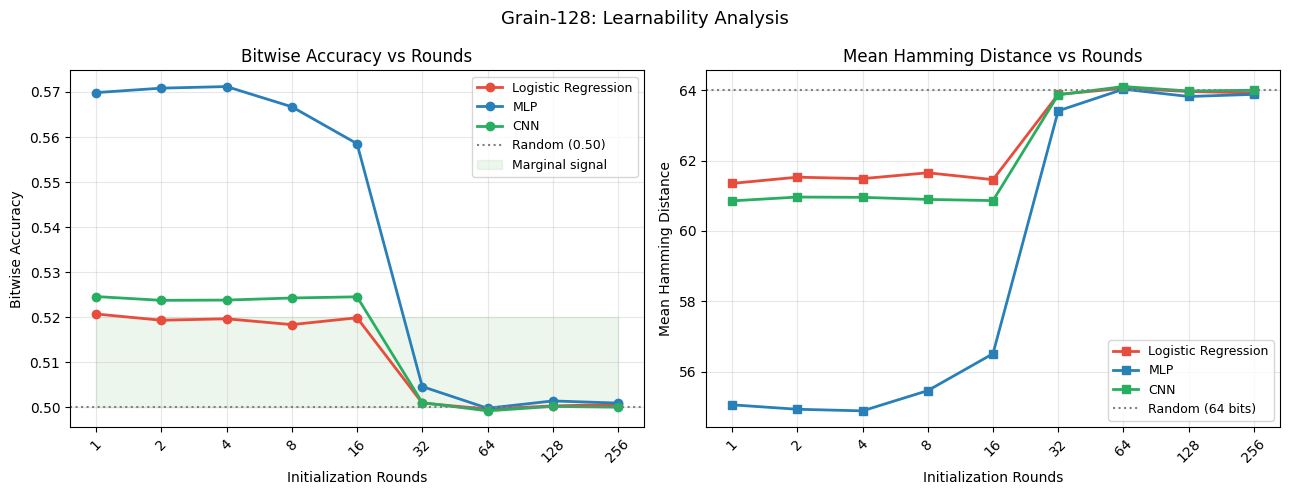

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for m_name, res in all_results.items():
    accs = [res[r]["bitwise_accuracy"] for r in ROUND_LIST]
    ax.plot(ROUND_LIST, accs, marker="o", linewidth=2,
            color=COLORS[m_name], label=LABELS[m_name])
ax.axhline(0.50, color="gray", linestyle=":", linewidth=1.5, label="Random (0.50)")
ax.fill_between(ROUND_LIST, 0.50, 0.52, alpha=0.07, color="green", label="Marginal signal")
ax.set_xscale("log", base=2)
ax.set_xticks(ROUND_LIST)
ax.set_xticklabels([str(r) for r in ROUND_LIST], rotation=45)
ax.set_xlabel("Initialization Rounds")
ax.set_ylabel("Bitwise Accuracy")
ax.set_title("Bitwise Accuracy vs Rounds")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
for m_name, res in all_results.items():
    hams = [res[r]["mean_hamming"] for r in ROUND_LIST]
    ax.plot(ROUND_LIST, hams, marker="s", linewidth=2,
            color=COLORS[m_name], label=LABELS[m_name])
ax.axhline(64, color="gray", linestyle=":", linewidth=1.5, label="Random (64 bits)")
ax.set_xscale("log", base=2)
ax.set_xticks(ROUND_LIST)
ax.set_xticklabels([str(r) for r in ROUND_LIST], rotation=45)
ax.set_xlabel("Initialization Rounds")
ax.set_ylabel("Mean Hamming Distance")
ax.set_title("Mean Hamming Distance vs Rounds")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle("Grain-128: Learnability Analysis", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "learnability_analysis.png"), dpi=150)
plt.show()

## 7. Generalization Evaluation (Unseen IVs)

**Phase I requirement**: Evaluate whether models generalize to IVs never seen during training.

We use a completely different RNG seed (`999` vs training seed `42`) to generate 5,000 fresh IVs.

In [15]:
NEW_SEED    = 999
NEW_SAMPLES = 5_000

def load_mlp(round_num):
    path = os.path.join(MODELS_DIR, f"mlp_r{round_num}.pt")
    if not os.path.exists(path):
        return None
    model = FastMLP().to(DEVICE)
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.eval()
    return model


@torch.no_grad()
def predict_mlp(model, X):
    Xt   = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    prob = torch.sigmoid(model(Xt)).cpu().numpy()
    return (prob >= 0.5).astype(np.float32), prob


def metrics_np(y_true, y_pred):
    bitacc  = float(np.mean(y_pred == y_true))
    hamming = float(np.mean(np.sum(np.abs(y_pred - y_true), axis=1)))
    exact   = float(np.mean(np.all(y_pred == y_true, axis=1)))
    return bitacc, hamming, exact


print("Generalisation setup:")
print(f"  New seed     : {NEW_SEED}  (vs training seed {SEED})")
print(f"  New samples  : {NEW_SAMPLES:,} fresh unseen IVs")

Generalisation setup:
  New seed     : 999  (vs training seed 42)
  New samples  : 5,000 fresh unseen IVs


In [16]:
gen_results  = {}
GEN_ROUND_LIST = [1, 2, 4, 8, 16, 32, 64, 256]

print("=" * 60)
print("  Grain-128 Generalisation Test (Unseen IVs)")
print("=" * 60)

for r in GEN_ROUND_LIST:
    print(f"\n  r = {r}")

    X_new, y_new = generate_dataset(
        init_rounds = r,
        num_samples = NEW_SAMPLES,
        key         = KEY,
        seed        = NEW_SEED,
        cache_dir   = "data/cache_grain_gen",
    )

    model = load_mlp(r)
    if model is None:
        print(f"    No checkpoint found for r={r} — run training cells first.")
        continue

    y_pred, prob        = predict_mlp(model, X_new)
    bitacc, ham, exact  = metrics_np(y_new, y_pred)

    gen_results[r] = {
        "bitwise_accuracy": bitacc,
        "mean_hamming":     ham,
        "exact_match":      exact,
    }

    delta = bitacc - 0.50
  
    print(f"    Bitwise accuracy : {bitacc:.4f}  ({delta:+.4f} vs random)")
    print(f"    Mean Hamming     : {ham:.2f} / 128 bits")
    print(f"    Exact match      : {exact:.6f}")

  Grain-128 Generalisation Test (Unseen IVs)

  r = 1
  [Cache] r=1: loaded from data/cache_grain_gen\grain_r1_cf6da163c3.pkl
    Bitwise accuracy : 0.5695  (+0.0695 vs random)
    Mean Hamming     : 55.10 / 128 bits
    Exact match      : 0.000000

  r = 2
  [Cache] r=2: loaded from data/cache_grain_gen\grain_r2_e6bc7a0adf.pkl
    Bitwise accuracy : 0.5696  (+0.0696 vs random)
    Mean Hamming     : 55.09 / 128 bits
    Exact match      : 0.000000

  r = 4
  [Cache] r=4: loaded from data/cache_grain_gen\grain_r4_c28997ebef.pkl
    Bitwise accuracy : 0.5701  (+0.0701 vs random)
    Mean Hamming     : 55.02 / 128 bits
    Exact match      : 0.000000

  r = 8
  [Cache] r=8: loaded from data/cache_grain_gen\grain_r8_c766abeea1.pkl
    Bitwise accuracy : 0.5654  (+0.0654 vs random)
    Mean Hamming     : 55.63 / 128 bits
    Exact match      : 0.000000

  r = 16
  [Cache] r=16: loaded from data/cache_grain_gen\grain_r16_2a71ebb5cf.pkl
    Bitwise accuracy : 0.5591  (+0.0591 vs random)
    

In [17]:
print("\n" + "=" * 58)
print("  GENERALISATION SUMMARY  (MLP on unseen IVs)")
print("=" * 58)
print(f"  {'Rounds':>8}  {'BitAcc':>8}  {'Hamming':>9}  {'vs Random':>10}")
print(f"  {'─'*48}")
for r, m in gen_results.items():
    delta = m['bitwise_accuracy'] - 0.50
    
    print(f"  {r:>8}  {m['bitwise_accuracy']:>8.4f}  {m['mean_hamming']:>9.2f}  {delta:>+10.4f}")
print("=" * 58)

# Compare with training test-split results
if gen_results:
    print("\n  TRAIN (test split) vs GENERALISATION (fresh IVs) — MLP")
    print(f"  {'─'*50}")
    print(f"  {'Rounds':>8}  {'Train BitAcc':>13}  {'Gen BitAcc':>11}  {'Gap':>6}")
    print(f"  {'─'*50}")
    for r in GEN_ROUND_LIST:
        if r not in gen_results or r not in all_results["mlp"]:
            continue
        tr  = all_results["mlp"][r]["bitwise_accuracy"]
        ge  = gen_results[r]["bitwise_accuracy"]
        gap = tr - ge
        print(f"  {r:>8}  {tr:>13.4f}  {ge:>11.4f}  {gap:>+6.4f}")
    print("\n  Gap ~ 0: model generalises well (no overfitting).")


  GENERALISATION SUMMARY  (MLP on unseen IVs)
    Rounds    BitAcc    Hamming   vs Random
  ────────────────────────────────────────────────
         1    0.5695      55.10     +0.0695
         2    0.5696      55.09     +0.0696
         4    0.5701      55.02     +0.0701
         8    0.5654      55.63     +0.0654
        16    0.5591      56.43     +0.0591
        32    0.5032      63.60     +0.0032
        64    0.5000      63.99     +0.0000
       256    0.4995      64.06     -0.0005

  TRAIN (test split) vs GENERALISATION (fresh IVs) — MLP
  ──────────────────────────────────────────────────
    Rounds   Train BitAcc   Gen BitAcc     Gap
  ──────────────────────────────────────────────────
         1         0.5699       0.5695  +0.0004
         2         0.5708       0.5696  +0.0012
         4         0.5712       0.5701  +0.0011
         8         0.5667       0.5654  +0.0013
        16         0.5585       0.5591  -0.0006
        32         0.5046       0.5032  +0.0014
       

## 8. Final Summary

All three models (LR, MLP, CNN) are compared across all initialization-round settings.

In [18]:

print("\n" + "=" * 75)
print("  FINAL RESULTS SUMMARY — Grain-128")
print("=" * 75)
print(f"  {'Rounds':>8} │ {'LR BitAcc':>10} │ {'MLP BitAcc':>11} │ {'CNN BitAcc':>11} │ {'Best':>8}")

for r in ROUND_LIST:
    lr_a  = all_results["lr" ][r]["bitwise_accuracy"]
    mlp_a = all_results["mlp"][r]["bitwise_accuracy"]
    cnn_a = all_results["cnn"][r]["bitwise_accuracy"]
    best  = max(lr_a, mlp_a, cnn_a)
    best_name = ["LR","MLP","CNN"][[lr_a,mlp_a,cnn_a].index(best)]
    
    print(f"  {r:>8} │ {lr_a:>10.4f} │ {mlp_a:>11.4f} │ {cnn_a:>11.4f} │ {best_name} {best:.4f}")
print("=" * 75)


# Find the max learnable rounds
learnable = []
for r in ROUND_LIST:
    best = max(all_results[m][r]["bitwise_accuracy"] for m in ["lr","mlp","cnn"])
    if best > 0.52:
        learnable.append(r)

if learnable:
    print(f"\n  Max learnable round count : r = {max(learnable)}")
else:
    print("\n  No round showed clear learning above 0.52 threshold.")


  FINAL RESULTS SUMMARY — Grain-128
    Rounds │  LR BitAcc │  MLP BitAcc │  CNN BitAcc │     Best
         1 │     0.5207 │      0.5699 │      0.5246 │ MLP 0.5699
         2 │     0.5193 │      0.5708 │      0.5237 │ MLP 0.5708
         4 │     0.5196 │      0.5712 │      0.5238 │ MLP 0.5712
         8 │     0.5183 │      0.5667 │      0.5243 │ MLP 0.5667
        16 │     0.5199 │      0.5585 │      0.5245 │ MLP 0.5585
        32 │     0.5009 │      0.5046 │      0.5010 │ MLP 0.5046
        64 │     0.4996 │      0.4998 │      0.4992 │ MLP 0.4998
       128 │     0.5003 │      0.5014 │      0.5002 │ MLP 0.5014
       256 │     0.5006 │      0.5009 │      0.5000 │ MLP 0.5009

  Max learnable round count : r = 16
